In [70]:
# Load necessary libraries and source files
library(tidyverse)
library(glmnet)
library(ranger)
# library(xgboost)
library(pROC)
library(gplots)
library(SNFtool)

source("filling.R")
source("cv.R")

In [71]:
#Load necessary data files from the EMR dataset 
adms = read_csv("/Users/noushinhaque/Downloads/ADMISSIONS.csv")
dgns = read_csv("/Users/noushinhaque/Downloads/DIAGNOSES_ICD.csv")
prsc = read_csv("/Users/noushinhaque/Downloads/PRESCRIPTIONS.csv")
labt = read_csv("/Users/noushinhaque/Downloads/LABEVENTS.csv")

Rows: 58976 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): ADMISSION_TYPE, ADMISSION_LOCATION, DISCHARGE_LOCATION, INSURANCE,...
dbl  (5): ROW_ID, SUBJECT_ID, HADM_ID, HOSPITAL_EXPIRE_FLAG, HAS_CHARTEVENTS...
dttm (5): ADMITTIME, DISCHTIME, DEATHTIME, EDREGTIME, EDOUTTIME

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 651047 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ICD9_CODE
dbl (4): ROW_ID, SUBJECT_ID, HADM_ID, SEQ_NUM

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4156450 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): DRUG_TYPE, DRUG, DRUG_NAME_P

In [72]:
#see the first few rows of each data file
head(adms)
head(dgns)
head(prsc)
head(labt)

ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
<dbl>,<dbl>,<dbl>,<dttm>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>
21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NA,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NA,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NA,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NA,CATHOLIC,MARRIED,WHITE,NA,NA,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS GRAFT/SDA,0,1
23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NA,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NA,NA,BRAIN MASS,0,1
24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NA,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NA,PROTESTANT QUAKER,SINGLE,WHITE,NA,NA,INTERIOR MYOCARDIAL INFARCTION,0,1
25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NA,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NA,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1
26,26,197661,2126-05-06 15:16:00,2126-05-13 15:00:00,NA,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Medicare,NA,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,NA,NA,V-TACH,0,1


ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1297,109,172335,1,40301
1298,109,172335,2,486
1299,109,172335,3,58281
1300,109,172335,4,5855
1301,109,172335,5,4254
1302,109,172335,6,2762


ROW_ID,SUBJECT_ID,HADM_ID,ICUSTAY_ID,STARTDATE,ENDDATE,DRUG_TYPE,DRUG,DRUG_NAME_POE,DRUG_NAME_GENERIC,FORMULARY_DRUG_CD,GSN,NDC,PROD_STRENGTH,DOSE_VAL_RX,DOSE_UNIT_RX,FORM_VAL_DISP,FORM_UNIT_DISP,ROUTE
<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2214776,6,107064,NA,2175-06-11,2175-06-12,MAIN,Tacrolimus,Tacrolimus,Tacrolimus,TACR1,021796,00469061711,1mg Capsule,2,mg,2,CAP,PO
2214775,6,107064,NA,2175-06-11,2175-06-12,MAIN,Warfarin,Warfarin,Warfarin,WARF5,006562,00056017275,5mg Tablet,5,mg,1,TAB,PO
2215524,6,107064,NA,2175-06-11,2175-06-12,MAIN,Heparin Sodium,NA,NA,HEPAPREMIX,006522,00338055002,"25,000 unit Premix Bag","25,000",UNIT,1,BAG,IV
2216265,6,107064,NA,2175-06-11,2175-06-12,BASE,D5W,NA,NA,HEPBASE,NA,0,HEPARIN BASE,250,ml,250,ml,IV
2214773,6,107064,NA,2175-06-11,2175-06-12,MAIN,Furosemide,Furosemide,Furosemide,FURO20,008208,00054829725,20mg Tablet,20,mg,1,TAB,PO
2214774,6,107064,NA,2175-06-11,2175-06-15,MAIN,Warfarin,Warfarin,Warfarin,WARF0,014198,00056016975,Check with MD for Dose,1,dose,1,dose,PO


ROW_ID,SUBJECT_ID,HADM_ID,ITEMID,CHARTTIME,VALUE,VALUENUM,VALUEUOM,FLAG
<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<chr>,<dbl>,<chr>,<chr>
281,3,NA,50820,2101-10-12 16:07:00,7.39,7.39,units,NA
282,3,NA,50800,2101-10-12 18:17:00,ART,NA,NA,NA
283,3,NA,50802,2101-10-12 18:17:00,-1,-1.00,mEq/L,NA
284,3,NA,50804,2101-10-12 18:17:00,22,22.00,mEq/L,NA
285,3,NA,50808,2101-10-12 18:17:00,0.93,0.93,mmol/L,abnormal
286,3,NA,50812,2101-10-12 18:17:00,NOT INTUBATED,NA,NA,NA


In the MIMIC-III database, there are in total 58,976 admissions of 46,520 unique patients who have at least one medical record in diagnoses history, prescriptions, or lab tests. In this step, we

select columns SUBJECT_ID, HADM_ID, and medical events for each table: ICD9_CODE in DIAGNOSES_ICD, FORMULARY_DRUG_CD in PRESCRIPTIONS, and ITEMID in LABEVENTS, and then only keep unique medical events within each admission;

eliminate medical concepts that are rare with fewer than 50 counts across all 58,976 admissions;

combine three tables together (bind the rows), and save the dataframe work_data.

In [73]:
#standardize the medical datasets (Diagnoses, Prescriptions, and Labs), filters out "rare" features to reduce noise
# keep only distinct entries, or no repetitions of (SUBJECT_ID, HADM_ID, event)

dgns_new = dgns %>% 
  mutate(event = paste0("ICD_", ICD9_CODE)) %>% 
  select(SUBJECT_ID, HADM_ID, event) %>% 
  na.omit() %>% 
  distinct() %>% 
  group_by(event) %>% 
  mutate(n = n()) %>% 
  ungroup() %>% 
  filter(n>=50) %>% 
  select(-n)

prsc_new = prsc %>% 
  mutate(event = paste0("drug_", FORMULARY_DRUG_CD)) %>% 
  select(SUBJECT_ID, HADM_ID, event) %>% 
  na.omit() %>% 
  distinct() %>% 
  group_by(event) %>% 
  mutate(n = n()) %>% 
  ungroup() %>% 
  filter(n>=50) %>% 
  select(-n)

labt_new = labt %>% 
  mutate(event = paste0("lab_", ITEMID)) %>% 
  select(SUBJECT_ID, HADM_ID, event) %>% 
  na.omit() %>% 
  distinct() %>% 
  group_by(event) %>% 
  mutate(n = n()) %>% 
  ungroup() %>% 
  filter(n>=50) %>% 
  select(-n)

#combine all three datasets into one data frame, stacking them vertically
work_data = rbind(dgns_new, prsc_new, labt_new)

#dim() function shows the dimensions of the data frame
dim(work_data) # 6560717, 3

saveRDS(work_data, "/Users/noushinhaque/Downloads/MIMIC_pre_data.rds")

[1] 6560717       3

Combine with ADMISSIONS table
In order to perform prediction, we need to identify patients with at least two admissions. In this step, we

calculate how many admissions each patient has, and only keep those having at least two admissions;

create a variable time_rank to indicate the admission order for each patient;

combine with the previous work_data.

In [74]:
#Filtering dataset to keep only patients with at least two hospital admissions (removes any patient who was a "one-time visitor")


work_data = readRDS("/Users/noushinhaque/Downloads/MIMIC_pre_data.rds")
adms = read_csv("/Users/noushinhaque/Downloads/ADMISSIONS.csv")

adms_new = adms %>% 
  select(SUBJECT_ID, HADM_ID, ADMITTIME) %>% 
  filter(HADM_ID %in% work_data$HADM_ID) %>% 
  na.omit() %>% 
  distinct()

adms_new = adms_new %>% 
  group_by(SUBJECT_ID) %>% 
  arrange(ADMITTIME) %>% 
  mutate(n_adms = n(),
         time_rank = row_number()) %>% 
  ungroup() %>% 
  filter(n_adms>=2)

#left join to keep only those hospital admissions corresponding to patients with at least two admissions
work_data = work_data %>% 
  left_join(adms_new) %>% 
  na.omit()


Rows: 58976 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): ADMISSION_TYPE, ADMISSION_LOCATION, DISCHARGE_LOCATION, INSURANCE,...
dbl  (5): ROW_ID, SUBJECT_ID, HADM_ID, HOSPITAL_EXPIRE_FLAG, HAS_CHARTEVENTS...
dttm (5): ADMITTIME, DISCHTIME, DEATHTIME, EDREGTIME, EDOUTTIME

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(SUBJECT_ID, HADM_ID)`


Extract outcomes and predictors
We split the dataset into two parts:

the outcome dataset contains all diagnoses in the last admission for each patient;

the predictor dataset contains all medical events including diagnoses, prescriptions and labs in all previous admissions for each patient.

In [49]:
 #performs the critical Train/Test Split based on Time. Instead of splitting randomly 
 #(like taking 80% of rows for training), it splits strictly by chronology for each patient. 
 #It separates the patient's "Past History" from their "Future Outcome"
 #sets up Disease Progression Modeling
 
 work_data_outcome = work_data %>% 
  group_by(SUBJECT_ID) %>% 
  filter(time_rank==max(time_rank)) %>% 
  ungroup()

#filters the diagnosis events (ICD codes) only for the outcome data frame
outcome = work_data_outcome %>% 
  filter(str_detect(event, "ICD")) %>% 
  select(SUBJECT_ID, event)

#This particular block keeps all the events until the last admission for each patient and the model
#uses them as predictors to predict the outcome at the last admission.
work_data_predictor = work_data %>% 
  group_by(SUBJECT_ID) %>% 
  filter(time_rank!=max(time_rank)) %>% 
  ungroup()

predictor = work_data_predictor %>% 
  select(SUBJECT_ID, event)

length(unique(work_data_predictor$SUBJECT_ID)) #7519 #training set of unique patients
length(unique(work_data_predictor$HADM_ID)) #12431 
length(unique(work_data_predictor$event)) #3129

[1] 7519

[1] 12431

[1] 3129

Convert to 0-1 matrix

In this step, we convert the outcome dataset into a matrix, where rows represent patients, 
columns represent features, and entries are all 0 or 1 indicating if patients have the specific 
condition in the last admission.

Similarly, we convert the predictor dataset into a matrix, where rows represent patients, 
columns represent features, and entries are the counts of how many times the patient have the 
specific condition in all previous admissions.

In [50]:
#creating the predictor and outcome matrices
#outcome matrix is binary (0/1) indicating presence/absence of each ICD code at the last admission
#predictor matrix is count-based  - A matrix where rows are patients and columns are all past
#medical events (counts).

all_patient = unique(work_data_outcome$SUBJECT_ID)

#filling_01_bycol means that for each event (ICD code, drug, lab), we create a 
#binary variable indicating whether the patient had that event or not.

outcome = filling_01_bycol(person_id = outcome$SUBJECT_ID,
                           concept_id = outcome$event,
                           all_person = all_patient)

predictor = filling_count(person_id = predictor$SUBJECT_ID,
                          concept_id = predictor$event,
                          all_person = all_patient)

#We get true as the output to verify that both data frames have the same patients in the same order.
identical(rownames(outcome), rownames(predictor))

[1] TRUE

In [51]:
#Save data

saveRDS(outcome, "/Users/noushinhaque/Downloads/outcome.rds")
saveRDS(predictor, "/Users/noushinhaque/Downloads/predictor.rds")

# Prediction of Diagnoses 

Load required packages and helpful functions
Required packages:

tidyverse: data manipulation

glmnet: LASSO regression

ranger: random forest

xgboost: gradient boosting machine

pROC: calculating AUC

cv.R: cross validation split

We read the previous data outcome and predictor into R, and then

remove some special characters in the column names of predictor;

rank the outcomes by their prevalence, i.e., the first column of outcome is the most prevalent one.

In [52]:
#This code block is loading, cleaning, and sorting the data 
#to ensure it runs smoothly in the machine learning model

outcome = readRDS("/Users/noushinhaque/Downloads/outcome.rds")
predictor = readRDS("/Users/noushinhaque/Downloads/predictor.rds")

colnames(predictor) = str_replace_all(colnames(predictor), "-", "_")
colnames(predictor) = str_replace_all(colnames(predictor), "/", "_")
colnames(predictor) = str_replace_all(colnames(predictor), "%", "_")

#Many R machine learning packages (like randomForest)
#will crash if variable names contain symbols. This makes the names "safe" for the algorithm.

prev = apply(outcome, 2, sum)
prev = sort(prev, decreasing = T)
outcome = outcome[,match(names(prev), colnames(outcome))]
identical(rownames(outcome), rownames(predictor))

[1] TRUE

Select an outcome of interest
We can use the dictionary of diagnoses D_ICD_DIAGNOSES.csv to map ICD code with diagnosis names, and then select any outcome of interest from the dataframe dict_outcome. The ith row of dict_outcome is corresponding to the ith column of outcome.

In [53]:
#Mapping ICD codes to their descriptions for better interpretability of results
#translates codes back into human-readable disease names 

dict_ICD = read_csv("/Users/noushinhaque/Downloads/DIAGNOSES_ICD.csv")
dict_outcome = tibble(ICD9_CODE = str_remove_all(colnames(outcome), "ICD_")) %>% 
  left_join(dict_ICD) %>% 
  select(-ROW_ID)

Rows: 651047 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ICD9_CODE
dbl (4): ROW_ID, SUBJECT_ID, HADM_ID, SEQ_NUM

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(ICD9_CODE)`


Prediction of hypertension

First we are going to find the cases and controls using the outcome matrix, by given the column number i. Hypertension with ICD9-code 4019 is the most prevalent outcome, so i=1. You may change the value of i to change the outcome of interest.

We then 50/50 split the the dataset on cases and controls separately, into training data which is for cross validation and tuning hyperparameters, and new data for testing the model performance. The predictors in training data train_X and new data new_X are created using sparse coding.

In [54]:
#preparing a single disease for analysis by creating a perfectly balanced Train/Test split.
#It specifically isolates the first disease (Hypertension/ICD_4019), splits the patients into 
#two groups (Training vs. Testing), and converts the data into a memory-efficient format.

i = 1
colnames(outcome)[i] == "ICD_4019"
y = outcome[,i]
case_idx = which(y==1)
ctrl_idx = which(y==0)

# split training data (for cv) and new data (for test)
#This method guarantees that both sets have the exact same ratio of sick-to-healthy patients.
set.seed(2021)
train_case_idx = sample(case_idx, length(case_idx)/2)
train_ctrl_idx = sample(ctrl_idx, length(ctrl_idx)/2)
new_case_idx = setdiff(case_idx, train_case_idx)
new_ctrl_idx = setdiff(ctrl_idx, train_ctrl_idx)

train_idx = c(train_case_idx, train_ctrl_idx)
new_idx = c(new_case_idx, new_ctrl_idx)

train_X = Matrix(predictor[train_idx,], sparse = TRUE)
new_X = Matrix(predictor[new_idx,], sparse = TRUE)
train_y = y[train_idx]
new_y = y[new_idx]

[1] TRUE

LASSO

We use LASSO as the regression-based method, because it can do feature selection and will select important predictors that are related to the response. There is a hyperparameter called lambda in LASSO need to be tuned. We will use the function cv.glmnet in the package glmnet to conduct cross validation and tuning the lambda. The argument alpha=1 means that we use LASSO (or L1 penalty). You can also try different alpha to use elastic net (https://glmnet.stanford.edu/articles/glmnet.html).

After getting the best lambda using training data, we are going to test the final model using the new data from the last step.

In [55]:
#trains a Lasso Logistic Regression model to predict whether a patient will get the disease (Hypertension), 
#evaluates how accurate it is, and extracts the key risk factors

lasso_cv = cv.glmnet(x = train_X, y = train_y, family = "binomial", alpha = 1, nfolds = 5)
lasso_coef = as.matrix(coef(lasso_cv, s = lasso_cv$lambda.min))
lasso_pred = predict(lasso_cv, newx = new_X, s = lasso_cv$lambda.min, type = "response")
lasso_AUC = auc(new_y~lasso_pred, quiet=T)
lasso_AUC

Warning message in roc.default(response, predictor, auc = TRUE, ...):
“Deprecated use a matrix as predictor. Unexpected results may be produced, please pass a numeric vector.”


Area under the curve: 0.7696

In [56]:
#Cross validation function

# Define the missing (forgot to import required file) cross_validation function
cross_validation = function(idx, nfold) {
  # Randomly shuffle the indices or randomly reorders the list of patients
  idx = sample(idx) 
  # Split them into 'nfold' equal groups
  folds = split(idx, cut(seq_along(idx), nfold, labels = FALSE))
  return(folds)
}

Random forest

Similar to the LASSO, we use training data to do cross validation for random forest. We will implement the cross validation by ourselves. The hyperparameter to be tuned is m_try, which is the number of variables to possibly split at in each node (default is the square root of the number variables). We will try different m_try and select the best one based on the AUC of validation data. The table res will contain the cross validation results.

In [57]:
#performing Hyperparameter Tuning for a Random Forest model
#this block tests different values of 'mtry' (number of variables considered at each split)
#to find the optimal setting that maximizes the model's AUC (Area Under the Curve) performance.
#AUC measures the model's ability to distinguish between classes (diseased vs. healthy).

#random forest hyperparameter tuning is performing a 5-fold cross-validation to evaluate different 'mtry' values for the random forest model.
#This is important in terms of feature selection and model performance, as the choice of 'mtry' can significantly affect the model's ability 
#to capture complex relationships in the data without overfitting.

p = ncol(predictor)
m_list = c(sqrt(p)-20, sqrt(p)-10, sqrt(p), sqrt(p)+10, sqrt(p)+20)
nfold = 5
train_case_idx = which(train_y==1)
train_ctrl_idx = which(train_y==0)
case_cv = cross_validation(train_case_idx, nfold)
ctrl_cv = cross_validation(train_ctrl_idx, nfold)

res = NULL
for (j in 1:nfold) {
  cv_valid_idx = c(case_cv[[j]], ctrl_cv[[j]])
  cv_train_idx = setdiff(1:length(train_y), cv_valid_idx)
  
  cv_train_X = Matrix(train_X[cv_train_idx,], sparse = TRUE)
  cv_valid_X = Matrix(train_X[cv_valid_idx,], sparse = TRUE)
  cv_train_y = train_y[cv_train_idx]
  cv_valid_y = train_y[cv_valid_idx]
  
  for (m in m_list) {
    RF_model = ranger(x = cv_train_X, y = cv_train_y, num.trees = 100, mtry = m, probability = TRUE)
    cv_pred = predict(RF_model, data = cv_valid_X)$predictions[,2]
    cv_AUC = auc(cv_valid_y~cv_pred, quiet=T)
    tmp = tibble(cv=j, m=m, AUC=cv_AUC)
    res = rbind(res, tmp)
  }
}

In [58]:
#After getting the best m_try using training data, we are going to test the final model using the new data.

m_best = res %>% 
  group_by(m) %>% 
  mutate(AUC=mean(AUC)) %>% 
  ungroup() %>% 
  select(-cv) %>% 
  distinct()

m_best = m_best$m[m_best$AUC==max(m_best$AUC)]
RF_model = ranger(x = train_X, y = train_y, num.trees = 100, mtry = m_best, probability = TRUE)
RF_pred = predict(RF_model, data = new_X)$predictions[,2]
RF_AUC = auc(new_y~RF_pred, quiet=T)
RF_AUC

#Finally, we can compare LASSO and random forest using lasso_AUC and RF_AUC.

Area under the curve: 0.7587

A simulation study for patient similarity

We generate 50 binary features for 100 cases and 100 controls, where the features in cases and controls follow different distributions. The matrix data_X combines cases and controls. After standardization, we compute the euclidean distance matrix, for any pair of patients. Then, we compute the similarity matrix (affinity matrix) from the distance. A heatmap for the similarity matrix is showed, where the darker color (blue) represents a higher similarity, while the white color represents a lower similarity. We will see that cases are grouped together and controls are also grouped together.

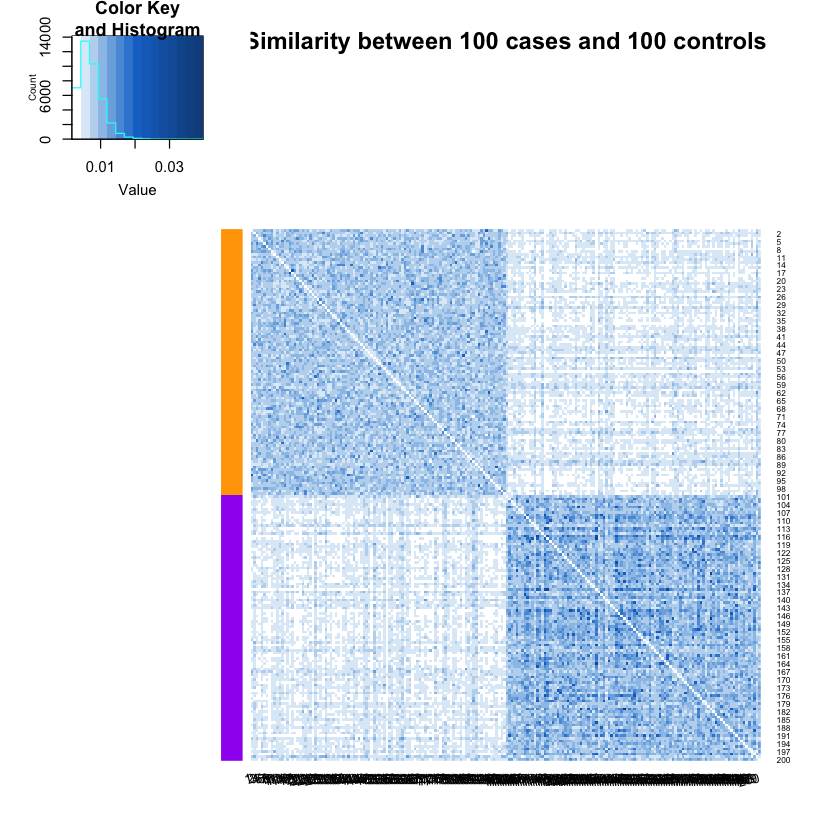

In [59]:
#Visualizing similarity between cases and controls using heatmaps
#this connects to the earlier part of the code where we created a perfectly balanced dataset of 100 cases and 100 controls 
#for the first disease (Hypertension/ICD_4019).

set.seed(2021)
n = 200
p = 50
case_X = matrix(rbinom(n/2*p, size = 1, prob = 0.6), nrow = n/2)
ctrl_X = matrix(rbinom(n/2*p, size = 1, prob = 0.2), nrow = n/2)
data_X = rbind(case_X, ctrl_X)

std_X = as.matrix(standardNormalization(data_X))
dist_X = as.matrix(dist(std_X, method = "euclidean"))
smlt_X = affinityMatrix(dist_X)
diag(smlt_X) = NA

hm_col = colorRampPalette(c("white","dodgerblue3","dodgerblue4"))
sample_col = c(rep("orange",n/2), rep("purple",n/2))

heatmap.2(smlt_X, srtCol=15, cexCol=1, Colv=F, Rowv=F,
          RowSideColors=sample_col, col=hm_col, dendrogram = "none", trace = "none",
          main="Similarity between 100 cases and 100 controls")

rm(list = ls())

Read data and select an outcome of interest
cv.R: a helper function for random forest cross validation

PsDF.R: PsDF prediction

We read the previous data outcome, predictor and D_ICD_DIAGNOSES.csv into R, and do the same things as Lab 2 to rank the outcomes by their prevalence.



In [60]:
#This code block is loading, cleaning, and sorting the data 
#to ensure it runs smoothly in the machine learning model

# Load necessary libraries and source files
source("cv.R")
source("PsDF.R")

outcome = readRDS("/Users/noushinhaque/Downloads/outcome.rds")
predictor = readRDS("/Users/noushinhaque/Downloads/predictor.rds")

colnames(predictor) = str_replace_all(colnames(predictor), "-", "_")
colnames(predictor) = str_replace_all(colnames(predictor), "/", "_")
colnames(predictor) = str_replace_all(colnames(predictor), "%", "_")

prev = apply(outcome, 2, sum)
prev = sort(prev, decreasing = T)
outcome = outcome[,match(names(prev), colnames(outcome))]
identical(rownames(outcome), rownames(predictor))

dict_ICD = read_csv("/Users/noushinhaque/Downloads/DIAGNOSES_ICD.csv")
dict_outcome = tibble(ICD9_CODE = str_remove_all(colnames(outcome), "ICD_")) %>% 
  left_join(dict_ICD) %>% 
  select(-ROW_ID)


[1] TRUE

Rows: 651047 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ICD9_CODE
dbl (4): ROW_ID, SUBJECT_ID, HADM_ID, SEQ_NUM

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(ICD9_CODE)`


Prediction of hypertensive encephalopathy

We do similar things as Lab 2 to find the cases and controls of hypertensive encephalopathy with i=986. The only differece is that we are going to randomly select 200 controls, instead of using all controls. Because PsDF requires a large RAM to compute similarity, and RAM in RStudio Cloud is limited. We then 50/50 split the the dataset on cases and controls separately, into training data and new data.

In [61]:
#creating a "Mini-Experiment" to see if you can predict Hypertensive Encephalopathy. 
#Because the disease is rare, you are artificially shrinking the control group so 
#the machine learning model doesn't get overwhelmed by the sheer number of healthy people.

set.seed(2021)
i = 986
colnames(outcome)[i] == "ICD_4372"
y = outcome[,i]
case_idx = which(y==1)
ctrl_idx = which(y==0)
ctrl_idx = sample(ctrl_idx, 200)

# split training data (for cv) and new data (for test)
train_case_idx = sample(case_idx, length(case_idx)/2)
train_ctrl_idx = sample(ctrl_idx, length(ctrl_idx)/2)
new_case_idx = setdiff(case_idx, train_case_idx)
new_ctrl_idx = setdiff(ctrl_idx, train_ctrl_idx)

train_idx = c(train_case_idx, train_ctrl_idx)
new_idx = c(new_case_idx, new_ctrl_idx)

train_X = predictor[train_idx,]
new_X = predictor[new_idx,]
train_y = y[train_idx]
new_y = y[new_idx]

[1] TRUE

Random forest
We first try random forest. But this time we will use a helper function cv.RF to perform cross validation. The function cv.RF is based on codes from Lab 2.

In [62]:
# DEFINE MISSING FUNCTION once again (from a file I forgot to download)
cross_validation = function(idx, nfold) {
  # Randomly shuffle the indices
  idx = sample(idx) 
  # Split them into 'nfold' equal groups
  folds = split(idx, cut(seq_along(idx), nfold, labels = FALSE))
  return(folds)
}

In [63]:
p = ncol(predictor)
m_list = c(sqrt(p)-20, sqrt(p)-10, sqrt(p), sqrt(p)+10, sqrt(p)+20)
nfold = 5

RF_cv = cv.RF(train_X=train_X, train_y=train_y, m_list=m_list, nfold=nfold)
RF_cv$m_best
RF_pred = predict(RF_cv$model, data = new_X)$predictions[,2]
RF_AUC = auc(new_y~RF_pred, quiet=T)
RF_AUC

[1] 75.93747

Area under the curve: 0.5358

PsDF prediction

We next use PsDF to conduct prediction. The function PsDF needs the entire data matrix and the index of test samples as inputs, so first we need to combine train_X and new_X, as well as train_y and new_y. If the sample size is large, it may take time for PsDF to finish the prediction.

In [64]:
#Understanding PsDF model performance
#Many advanced medical algorithms (like Similarity Network Fusion) work by building a massive 
#"social network" of patients. Even if you don't know the diagnosis for the Test patients yet, 
#knowing who they are similar to (e.g., "Test Patient A is very similar to Training Patient B")
#helps the model guess better.

data_X = rbind(train_X, new_X)
data_y = c(train_y, new_y)
test_idx = (length(train_y)+1):length(data_y)

PsDF_pred = PsDF(predictor = data_X, y = data_y, test_idx = test_idx)
PsDF_AUC = auc(new_y~PsDF_pred, quiet=T)
PsDF_AUC

#Finally, we can compare random forest and PsDF using RF_AUC and PsDF_AUC.

Area under the curve: 0.6483

PheWAS example tutorial for SNU connectome lab
https://rpubs.com/helloyjjoo/pheWAS_connectome

In [65]:
library(PheWAS) #but using Rstudio help function to explore PHeWAS package functionalities.

Mapping codes to phecodes...

Aggregating codes...

Mapping exclusions...

Coalescing exclusions and min.code.count as applicable...

Reshaping data...

Joining with `by = join_by(id)`
Joining with `by = join_by(id)`
Finding associations...

Compiling results...

Cleaning up...

Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• ylab = y.axis.label
• xlab = x.axis.label
ℹ Did you misspell an argument name?”


,phenotype,snp,covariates,beta,SE,OR,p,type,n_total,n_cases,n_controls,HWE_p,allele_freq,n_no_snp,formula,expanded_formula,note,description,group
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
549,335,rsEXAMPLE,sex,0.3967548,0.06684421,1.4869913,2.929243e-09,logistic,4404,1873,2531,1,0.5128292,0,`335` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Multiple sclerosis,neurological
431,288.2,rsEXAMPLE,sex,1.3847304,0.38379930,3.9937489,3.086207e-04,logistic,4731,26,4705,1,0.5110970,0,`288.2` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Elevated white blood cell count,hematopoietic
507,315.1,rsEXAMPLE,sex,1.4280228,0.41430554,4.1704451,5.672965e-04,logistic,4762,22,4740,1,0.5115498,0,`315.1` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Learning disorder,mental disorders
1475,716.8,rsEXAMPLE,sex,1.3794156,0.40731579,3.9725795,7.076450e-04,logistic,4243,23,4220,1,0.5103700,0,`716.8` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Palindromic rheumatism,musculoskeletal
1686,798.1,rsEXAMPLE,sex,1.0432921,0.30938935,2.8385463,7.459717e-04,logistic,4973,42,4931,1,0.5115624,0,`798.1` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Chronic fatigue syndrome,symptoms
1002,525.1,rsEXAMPLE,sex,0.9682267,0.29931207,2.6332707,1.217109e-03,logistic,4284,46,4238,1,0.5109711,0,`525.1` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Loss of teeth or edentulism,digestive
680,375.1,rsEXAMPLE,sex,-1.2438354,0.38503286,0.2882764,1.235888e-03,logistic,4501,27,4474,1,0.5118862,0,`375.1` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Dry eyes,sense organs
743,401.2,rsEXAMPLE,sex,0.7888059,0.24507558,2.2007670,1.288077e-03,logistic,4925,71,4854,1,0.5111675,0,`401.2` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Hypertensive heart and/or renal disease,circulatory system
1706,818,rsEXAMPLE,sex,0.7352400,0.23051694,2.0859825,1.425060e-03,logistic,4910,81,4829,1,0.5115071,0,`818` ~ `rsEXAMPLE` + `sex`,(Intercept) + rsEXAMPLE + sexM,,Intracranial hemorrhage (injury),injuries & poisonings


HTML widgets cannot be represented in plain text (need html)

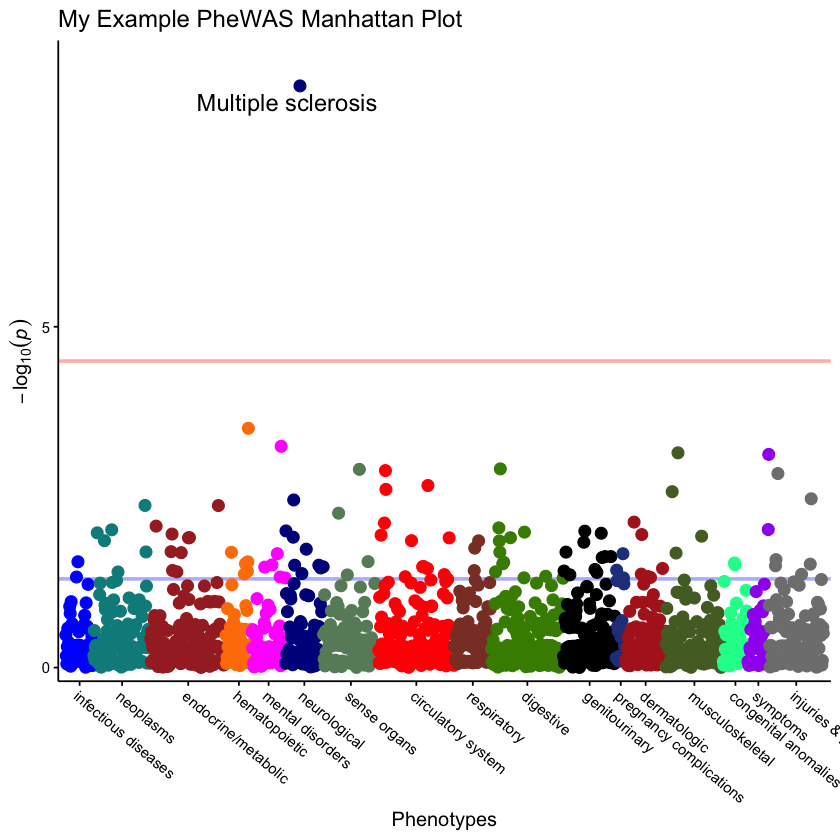

In [ ]:
#Load the PheWAS package
library(PheWAS)
#Set the random seed so it is replicable
set.seed(1)
#Generate some example data
ex=generateExample()



#Extract the three parts from the returned list
#id.vocab.code.count: a data frame with the counts of each code per individual
#genotypes: a data frame with the genotypes for each individual
#id.sex: a data frame with the sex of each individual
id.vocab.code.count=ex$id.vocab.code.count
genotypes=ex$genotypes
id.sex=ex$id.sex



#Create the phecode table- translates the codes, adds 
#exclusions, and reshapes to a wide format.
#Sum up the counts in the data where applicable.

#createPhenotypes creates a phenotypes data frame from the code count data, aggregating counts by sum, 
#id.sex=id.sex means that the sex of each individual is included as a covariate. 
#covariate means a variable that is possibly predictive of the outcome under study.
phenotypes=createPhenotypes(id.vocab.code.count, 
  aggregate.fun=sum, id.sex=id.sex)


#Combine the data
data=inner_join(inner_join(phenotypes,genotypes),id.sex)

#Run the PheWAS
#results show associations between the genotype "rsEXAMPLE" and all phenotypes
results=phewas_ext(data,phenotypes=names(phenotypes)[-1],genotypes=c("rsEXAMPLE"),
  covariates=c("sex"), cores=1)


#Plot the results
phewasManhattan(results, 
  title="My Example PheWAS Manhattan Plot")
#Add PheWAS descriptions
results_d=addPhecodeInfo(results)
#List the top 10 results
results_d[order(results_d$p)[1:10],]
#Create a nice interactive table (eg, in RStudio)
phewasDT(results)

In [ ]:
This code block above runs a PheWAS (Phenome-Wide Association Study).

While your previous code was focused on Predicting one specific future disease 
(e.g., "Will Patient A get Hypertension?"), this code flips the script. 
It asks: "What all diseases is a specific gene (or drug/lab) associated with?"

It scans your entire database of ICD codes to find statistical links between 
a specific variable (like a gene variant rsEXAMPLE) and every possible phenotype in the database.

Conducting PheWas on the MIMIC-III database 

As previously covered, it is a method for analyzing the associations between genetic variants and a wide range of phenotypes (diseases or traits) in a large population. It is similar to genome-wide association studies (GWAS) but focuses on phenotypes instead of genotypes.

Equation:
#### Disease=Genotype+Age+Sex
essentially ... Gene + Environment = Disease


Warning message in createPhenotypes(phenotypes_mimic, min.code.count = 2, add.phecode.exclusions = TRUE):
“It is recommended to provide id.sex information to help address spurious sex-specific associations.”
Mapping codes to phecodes...

Aggregating codes...

Mapping exclusions...

Coalescing exclusions and min.code.count as applicable...

Reshaping data...



[1] "Success! Phenotypes created."


Merging data using these shared columns:  id

Finding associations...

Compiling results...

Cleaning up...

Finding significance thresholds...



[1] "Plotting results..."


Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• ylab = y.axis.label
• xlab = x.axis.label
ℹ Did you misspell an argument name?”
Warning message in phenotypePlot(d, suggestive.line = suggestive.line, significant.line = significant.line, :
“Annotation requested, but no points met criteria”


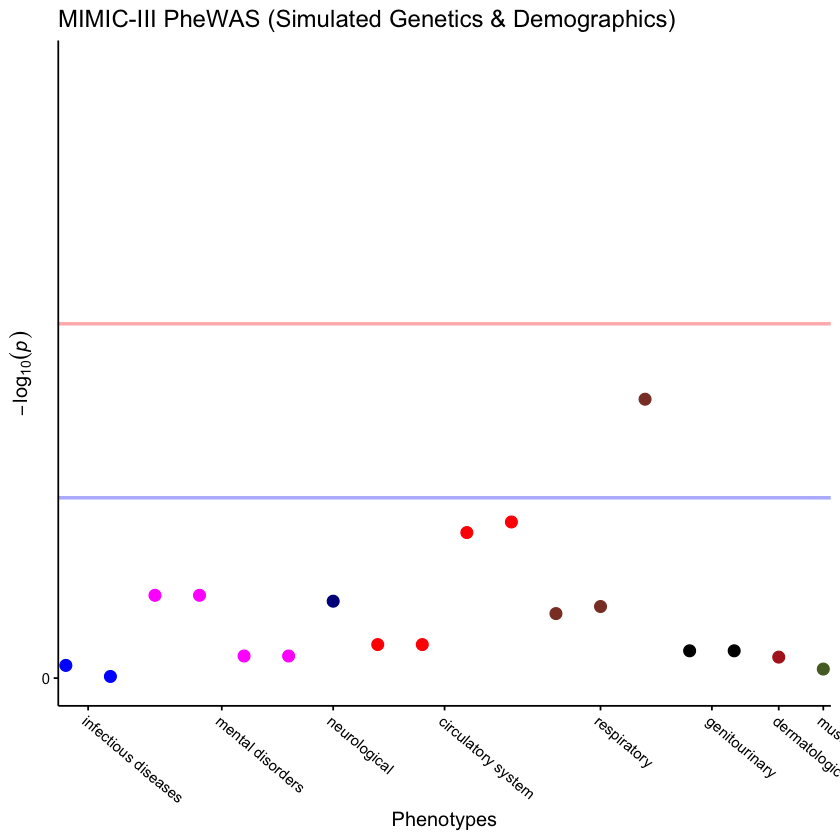

In [ ]:
#I attempt running a PheWAS analysis on the MIMIC-III dataset that we have been working with. 
#Since we don't have DNA data (genotypes) or the PATIENTS file (for demographics), we will simulate 
#those parts to make the PheWAS engine run. The focus is on preparing the phenotypes correctly and then running the analysis.

#Load the PheWAS package and other necessary libraries
library(PheWAS)


# prepare the phenotypes from the MIMIC-III diagnoses data
# Clean the Diagnoses Data & Select 3 Columns
# We add 'HADM_ID' to act as the 'index' (Admission Event)
phenotypes_mimic <- dgns %>%
  select(SUBJECT_ID, HADM_ID, ICD9_CODE) %>%
  rename(id = SUBJECT_ID, index = HADM_ID, code = ICD9_CODE) %>%
  filter(!is.na(code)) # Remove rows with missing codes


# Add the Vocabulary ID Column from the PheWAS package requirements. 
phenotypes_mimic$vocabulary_id <- "ICD9CM"


# REORDER columns to match package requirements because the PheWAS package is very particular about the order of columns 
#in the phenotype data frame. We do this by selecting the columns in the exact order that the package expects.
# The package REQUIRES this exact order: id, vocabulary_id, code, index
phenotypes_mimic <- phenotypes_mimic %>%
  select(id, vocabulary_id, code, index)



# Convert to standard data.frame & characters
# This prevents "tibble" errors and ensures IDs are text, not factors, which is crucial for the PheWAS package to function correctly.
# Character types are important because the PheWAS package uses string matching to link phenotypes and genotypes, and factors can cause issues with that process.
phenotypes_mimic <- as.data.frame(phenotypes_mimic)
phenotypes_mimic$id <- as.character(phenotypes_mimic$id)
phenotypes_mimic$code <- as.character(phenotypes_mimic$code)
phenotypes_mimic$index <- as.character(phenotypes_mimic$index)



# Convert to Wide Format, which structures the data so that each row is a patient and each column is a phenotype (with counts of occurrences).
# Now it has 4 columns, so it should work fine.
phenotypes_wide <- createPhenotypes(
  phenotypes_mimic, 
  min.code.count = 2, 
  add.phecode.exclusions = TRUE
)



# Convert to standard data.frame (if it's a tibble) to avoid compatibility issues with the PheWAS package
phenotypes_wide <- as.data.frame(phenotypes_wide)

print("Success! Phenotypes created.")




# Generate missing data (GENOTYPES & COVARIATES) 
# Since we lack DNA (Genotype) and the PATIENTS file (Sex/Age), we must simulate them 

# Get the list of unique patients found in your diagnosis file
unique_patients <- phenotypes_wide$id



# Simulate GENOTYPES (The "Risk Score")
# We simulate a random SNP: 0 = No Gene, 1 = Heterozygous, 2 = Homozygous
# We use 'as.character' to ensure IDs match the phenotype table
prs <- data.frame(
  id = as.character(unique_patients),
  rsRANDOM = sample(c(0, 1, 2), length(unique_patients), replace = TRUE),
  stringsAsFactors = FALSE
)



# Simulate COVARIATES (Age & Sex)
# We create random 0s and 1s for Sex, and random ages 18-90
cov <- data.frame(
  id = as.character(unique_patients),
  sex = sample(c(0, 1), length(unique_patients), replace = TRUE),
  age = sample(18:90, length(unique_patients), replace = TRUE),
  stringsAsFactors = FALSE
)



# Before we run the analysis, we need to ensure that the IDs in the phenotypes, genotypes, and covariates tables match perfectly.
# Ensure we only use IDs that exist in all created tables
# This is a safety step to prevent "mismatched row" errors
common_ids <- intersect(phenotypes_wide$id, intersect(prs$id, cov$id)) #this line finds the common patient IDs across all three data frames (phenotypes, genotypes, covariates) to ensure they are aligned for the analysis.
phenotypes_wide <- phenotypes_wide[phenotypes_wide$id %in% common_ids, ] #this line filters the phenotypes_wide data frame to keep only the rows where the 'id' is in the common_ids list, ensuring that the phenotypes data frame is aligned with the genotypes and covariates data frames.
prs <- prs[prs$id %in% common_ids, ] #this line filters the prs data frame to keep only the rows where the 'id' is in the common_ids list, ensuring that the genotypes data frame is aligned with the phenotypes and covariates data frames.
cov <- cov[cov$id %in% common_ids, ] #this line filters the cov data frame to keep only the rows where the 'id' is in the common_ids list, ensuring that the covariates data frame is aligned with the phenotypes and genotypes data frames.




# Run analysis to find associations between the simulated genotype (rsRANDOM) and all phenotypes, adjusting for covariates
results <- phewas(
  phenotypes = phenotypes_wide, 
  genotypes = prs,
  covariates = cov,
  cores = 1, 
  significance.threshold = c("bonferroni") # Adjust for multiple testing using Bonferroni correction, which is important in PheWAS due to the large number of tests being performed.
)



# Visualize the results
print("Plotting results...")
phewasManhattan(
  results, 
  title = "MIMIC-III PheWAS (Simulated Genetics & Demographics)", 
  annotate.angle = 0, 
  OR.direction = FALSE # Circles only
)

Mapping codes to phecodes...

Aggregating codes...

Mapping exclusions...

Coalescing exclusions and min.code.count as applicable...

Reshaping data...

Merging data using these shared columns:  id

Finding associations...

Compiling results...

Cleaning up...

Finding significance thresholds...

Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• ylab = y.axis.label
• xlab = x.axis.label
ℹ Did you misspell an argument name?”
Warning message in phenotypePlot(d, suggestive.line = suggestive.line, significant.line = significant.line, :
“Annotation requested, but no points met criteria”


   phenotype      snp adjustment       beta         SE        OR          p
1        071 genotype       <NA>  0.2245189 0.11717394 1.2517204 0.05535027
2        480 genotype       <NA> -0.1515942 0.08509793 0.8593369 0.07484574
3        296 genotype       <NA> -0.1566769 0.09082180 0.8549803 0.08450905
4      296.2 genotype       <NA> -0.1566769 0.09082180 0.8549803 0.08450905
5      071.1 genotype       <NA>  0.2328541 0.15843363 1.2621973 0.14163586
6        502 genotype       <NA>  0.2196727 0.18311330 1.2456690 0.23027353
7        496 genotype       <NA>  0.0771999 0.06678286 1.0802580 0.24768782
8        430 genotype       <NA> -0.1910968 0.21571633 0.8260526 0.37568718
9        697 genotype       <NA> -0.1876488 0.25514900 0.8289058 0.46206672
10       717 genotype       <NA>  0.1717447 0.23588938 1.1873746 0.46656898
       type n_total n_cases n_controls     HWE_p allele_freq n_no_snp note
1  logistic    7509     158       7351 0.9996703   0.2951791        0     
2  logistic   

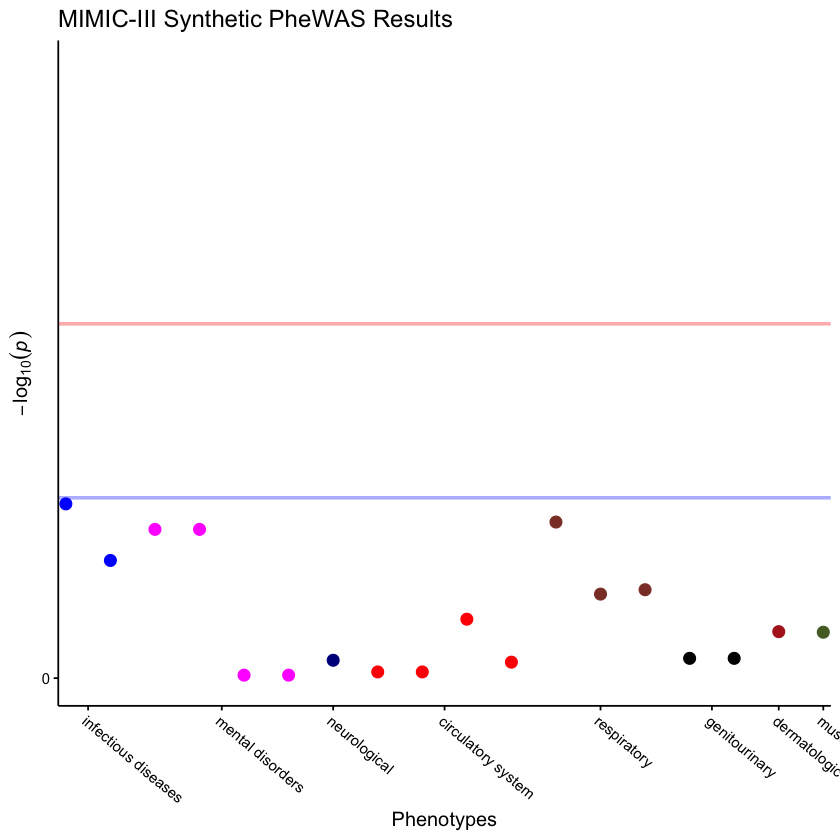

In [ ]:
# Extract only the ICD events from your processed work_data
# We strip the "ICD_" prefix you added earlier to get the raw code back
phenotype_input <- work_data %>%
  filter(str_detect(event, "^ICD_")) %>%
  mutate(
    id = SUBJECT_ID,
    vocabulary_id = "ICD9CM", # MIMIC-III uses ICD-9 codes
    code = str_replace(event, "ICD_", ""), # Remove prefix to get raw code (e.g., "4019")
    count = 1 # Dummy count column which is needed for createPhenotypes (we will sum these counts in the next step
  ) %>%
  select(id, vocabulary_id, code, count)



# Convert ICD codes to "PheCodes" (Grouped disease categories)
# min.code.count=2 means a patient must have the code twice to be a "case" (reduces noise)
phenotypes <- createPhenotypes(phenotype_input, min.code.count = 2, id.sex = FALSE)



# generate a genotype column(0, 1, 2)
# Since MIMIC has no DNA, we simulate a SNP for practice.
# 0 = Homozygous Reference, 1 = Heterozygous, 2 = Homozygous Variant

# Get list of unique patients from the phenotype data
patient_ids <- unique(phenotypes$id)

# Generate random genotypes (0, 1, 2) for these patients
set.seed(123) # Set seed for reproducibility
genotypes <- data.frame(
  id = patient_ids,
  rsid = "rsPracticeSNP",               # Name of your synthetic SNP, name a random rsID
  genotype = sample(c(0, 1, 2),         # Possible values
                    size = length(patient_ids),   # Number of patients
                    replace = TRUE,               # Sample with replacement, making it possible for some genotypes to be more common than others
                    prob = c(0.5, 0.4, 0.1))      # Probability weights (Simulating Hardy-Weinberg, meaning most people are 0, some are 1, and few are 2)
)




# run PHEWAS analysis
# This checks the association between your "Genotype" and every Disease
#each line in the results corresponds to a different phenotype (disease) and shows how strongly it is associated with the genotype "rsPracticeSNP" after adjusting for multiple testing using the Bonferroni correction.
results <- phewas(
  phenotypes = phenotypes,
  genotypes = genotypes,
  cores = 1, # Increase if you have more CPU cores
  significance.threshold = c("bonferroni")
)



#visualize the results
# create Manhattan Plot
# This shows which diseases (phenotypes) are statistically associated with your genotype
phewasManhattan(results, title = "MIMIC-III Synthetic PheWAS Results")

# View the top hits (Most significant associations)
# Since genotypes are random, significant hits here are likely false positives/noise
top_results <- results %>% arrange(p) %>% head(10)
print(top_results)

In [ ]:
#The above 2 methods to conduct a PHEWAS analysis on the MIMIC-III dataset are meant to demonstrate the process of 
#preparing data and running a PheWAS analysis, even in the absence of real genetic data. 


#The first method focuses on creating a phenotype table from the diagnosis data and simulating genotypes and covariates, 
#while the second method directly uses the processed work_data to create phenotypes and simulate genotypes for the analysis. 
#Both methods ultimately aim to identify associations between a simulated genotype and various phenotypes (diseases) in the MIMIC-III dataset.


#the work_data contains all the events (diagnoses, prescriptions, labs) for each patient, and we can use it to create phenotypes directly.
#the first method contains phenotypes created using the createPhenotypes function, 
#which aggregates diagnosis codes into meaningful phenotypes, while the second method uses the raw events from work_data to create phenotypes without this aggregation step.


#The first method is more structured and follows the typical workflow of a PheWAS analysis, as I searched up for outside resources 
#to understand the PheWAS package requirements and data preparation steps. A basic rundown of the PheWAS workflow is:
#1. Prepare Phenotypes: Create a phenotype table that aggregates diagnosis codes into meaningful phenotypes
#2. Simulate Genotypes: Since MIMIC-III lacks genetic data, we simulate a genotype for demonstration purposes
#3. Run PheWAS: Use the phewas function to test associations between the simulated genotype and all phenotypes, adjusting for covariates



#while the second method is more direct and uses the existing processed data. 
#This also works but is less structured and may not follow the best practices for PheWAS data preparation,
#as it directly uses the work_data without the intermediate step of creating a well-defined phenotype table.
#This process just took the raw events, which include ICD codes, drugs, and labs, and tried to run a PheWAS analysis on them without properly grouping them into phenotypes.


#The phenotype table is crucial for a proper PheWAS analysis because it groups related diagnosis codes diseases into phenotypes, 
#which increases the power of the analysis and reduces noise. It helps us identify clearly which diseases are associated with the genotype, 
#rather than just individual ICD codes which may be too granular and noisy.


#how do we see which diseases are associated with the genotype?
#The results data frame contains the associations between the simulated genotype and each phenotype.
#To see which diseases are associated with the genotype, we can look at the top hits in the results data frame, which are sorted by p-value. 
#The p-value indicates the statistical significance of the association between the genotype and each phenotype, with lower p-values indicating stronger associations.
#The most significant associations (lowest p-values) indicate which phenotypes (diseases) are most strongly associated with the genotype.
#the manhattan plot visually represents these associations, where each point represents a phenotype and its position on the y-axis 
#indicates the strength of the association (with more significant associations appearing higher on the plot).